In [25]:
using Pkg
Pkg.add("Plots")
Pkg.add("BenchmarkTools")

   Resolving package versions...
     Project No packages added to or removed from `D:\HCMUS\HK7\DM\lab2\DataMiningLab2\Project.toml`
    Manifest No packages added to or removed from `D:\HCMUS\HK7\DM\lab2\DataMiningLab2\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `D:\HCMUS\HK7\DM\lab2\DataMiningLab2\Project.toml`
    Manifest No packages added to or removed from `D:\HCMUS\HK7\DM\lab2\DataMiningLab2\Manifest.toml`


In [26]:
using Plots
using BenchmarkTools

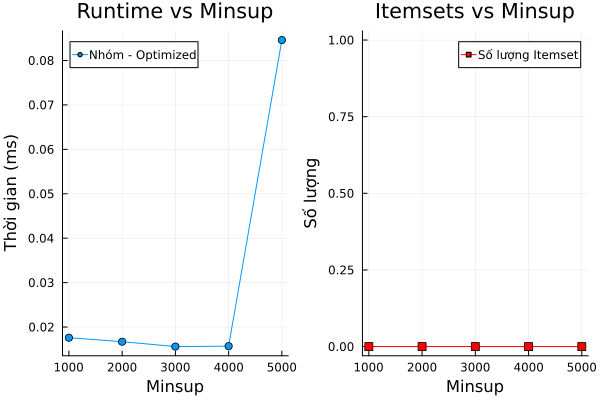

"d:\\HCMUS\\HK7\\DM\\lab2\\DataMiningLab2\\results\\declat_minsup_analysis.png"

In [29]:
include("../src/utils.jl")
include("../src/algorithm/declat.jl")

# Mảng chứa các giá trị minsup từ cao xuống thấp
minsups = [5000, 4000, 3000, 2000, 1000]
runtimes = Float64[]
itemset_counts = Int[]

# Đọc dữ liệu 1 lần duy nhất
transactions = read_spmf("../data/toy/test.txt")

for ms in minsups
    # Ép dọn rác trước khi đo
    GC.gc()

    # Đo thời gian chạy optimized
    t = @elapsed result = run_declat(transactions, ms; mode=:optimized)

    push!(runtimes, t * 1000)
    push!(itemset_counts, length(result))
end

# Vẽ 2 biểu đồ cạnh nhau
p1 = plot(minsups, runtimes, marker=:circle, label="Nhóm - Optimized",
          xlabel="Minsup", ylabel="Thời gian (ms)", title="Runtime vs Minsup")

p2 = plot(minsups, itemset_counts, marker=:square, color=:red, label="Số lượng Itemset",
          xlabel="Minsup", ylabel="Số lượng", title="Itemsets vs Minsup")

final_plot = plot(p1, p2, layout=(1, 2))
display(final_plot)
savefig(final_plot, "../results/declat_minsup_analysis.png")